In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict , Literal


In [2]:
class QuadraticState(TypedDict):
  a: float
  b: float
  c: float
  equation: str
  discriminant: float
  results: str

In [8]:
def showEquation(state: QuadraticState) -> QuadraticState:
  equation = f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"
  return {'equation': equation}

In [4]:
def calculateDiscriminant(state: QuadraticState) -> QuadraticState:
  discriminant = state['b']**2 - 4*state['a']*state['c']
  return {'discriminant': discriminant}

In [15]:
def realRoots(state: QuadraticState) -> QuadraticState:
  sqrt_disc = state['discriminant']**0.5
  root1 = (-state['b'] + sqrt_disc) / (2*state['a'])
  root2 = (-state['b'] - sqrt_disc) / (2*state['a'])
  results = f"Real roots: {root1}, {root2}"
  return {'results': results}

def repeatedRoots(state: QuadraticState) -> QuadraticState:
  root = -state['b'] / (2*state['a'])
  results = f"Repeated root: {root}"
  return {'results': results}

def noRealRoots(state: QuadraticState) -> QuadraticState:
  results = "No real roots"
  return {'results': results}

def checkConditions(state: QuadraticState) -> Literal['realRoots', 'repeatedRoots', 'noRealRoots']:
  if state['discriminant'] > 0:
    return 'realRoots'
  elif state['discriminant'] == 0:
    return 'repeatedRoots'
  else:
    return 'noRealRoots'

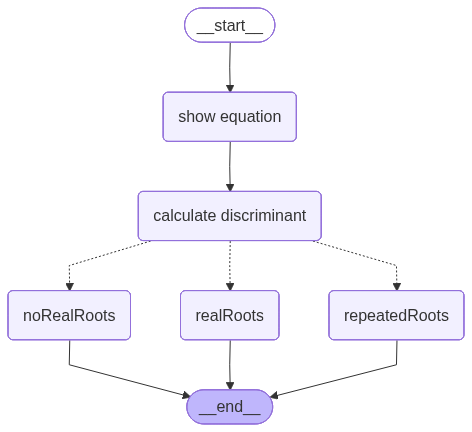

In [16]:
graph = StateGraph(QuadraticState)

graph.add_node('show equation', showEquation)
graph.add_node('calculate discriminant', calculateDiscriminant)
graph.add_node('realRoots', realRoots)
graph.add_node('repeatedRoots', repeatedRoots)
graph.add_node('noRealRoots', noRealRoots)

graph.add_edge(START, 'show equation')
graph.add_edge('show equation', 'calculate discriminant')
graph.add_conditional_edges('calculate discriminant', checkConditions)
graph.add_edge('realRoots', END)
graph.add_edge('repeatedRoots', END)
graph.add_edge('noRealRoots', END)


workflow = graph.compile()
workflow

In [17]:
initial_state = {
  'a': 1,
  'b': -3,
  'c': 2
}
result = workflow.invoke(initial_state)
print(result)

{'a': 1, 'b': -3, 'c': 2, 'equation': '1x^2 + -3x + 2 = 0', 'discriminant': 1, 'results': 'Real roots: 2.0, 1.0'}
